# 6-Dot Quantum Device GDS Layout Generator
## 6 Quantum Dot Device GDS Layout Generator

Based on image `image_1773139486280.png`.

**Two device designs available:**
1. **Standard Design**: SG/BG/PG gates (gray/pink/purple)
2. **Al Ohmic Design**: Ohmic/Accumulation/Screening gates (green/blue/orange)

---

In [1]:
# Run script to generate devices
import subprocess
import os

# Set working directory
work_dir = r"C:\Users\Administrator\Desktop\Spin_Quantum_Hardware_Simulation\GDS_Drawer\6-dot"
os.chdir(work_dir)

# Run Python script
result = subprocess.run(
    ["python", "six_dot_generator.py"],
    cwd=work_dir,
    capture_output=True,
    encoding="utf-8",
    errors="ignore"
)

print("Script executed!")
if result.returncode == 0:
    print("GDS files generated.")
else:
    print("Error:", result.stderr)

Script executed!
GDS files generated.


## Device 1: Standard Design (SG/BG/PG)

Standard 6-dot quantum device with Screen Gate, Barrier Gate, and Plunger Gate.

In [2]:
# Read and visualize standard device
import gdstk
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon

work_dir = r"C:\Users\Administrator\Desktop\Spin_Quantum_Hardware_Simulation\GDS_Drawer\6-dot\output_6dot"

# Read GDS file
lib = gdstk.read_gds(os.path.join(work_dir, "6qd_device_core.gds"))
cell = lib["6QD_DEVICE_CORE"]

print(f"Device: {cell.name}")
print(f"Polygon count: {len(cell.polygons)}")

Device: 6QD_DEVICE_CORE
Polygon count: 27


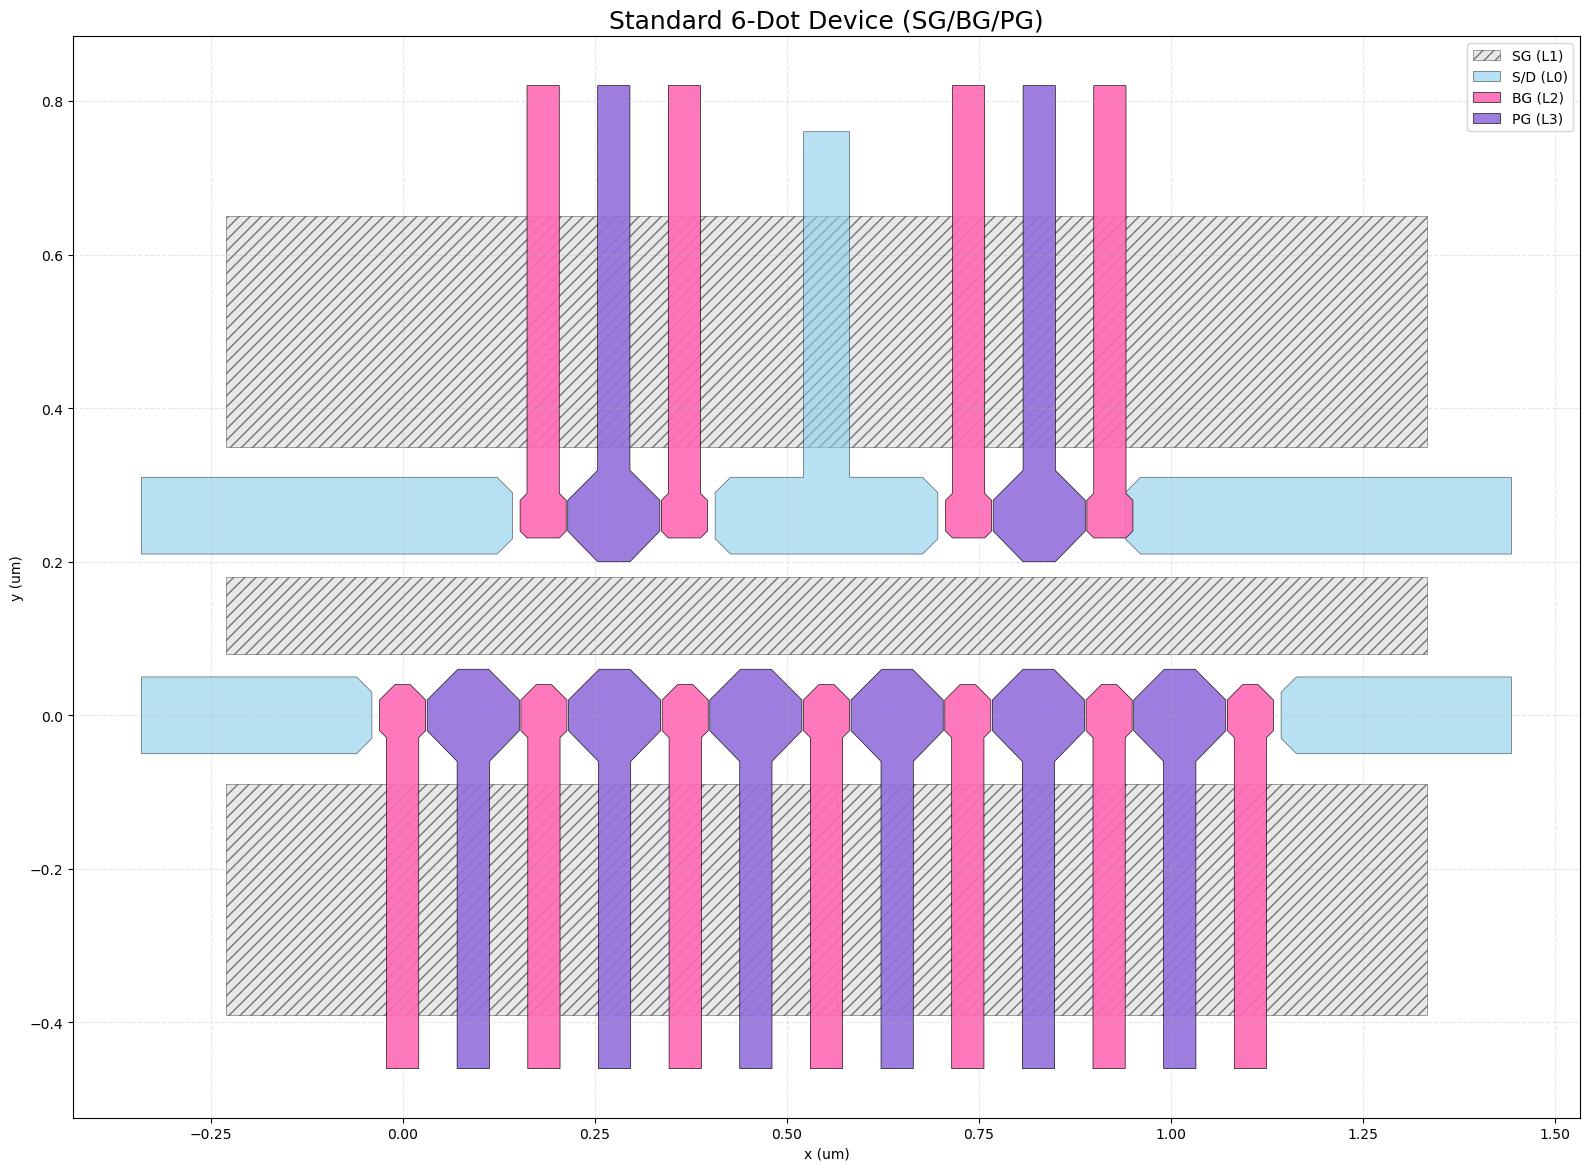

In [3]:
# Visualize standard device
fig, ax = plt.subplots(figsize=(16, 12))
ax.set_title("Standard 6-Dot Device (SG/BG/PG)", fontsize=18)

# Layer color config
layer_config = {
    0: {'color': '#87CEEB', 'alpha': 0.6, 'label': 'S/D (L0)'},
    1: {'color': '#D3D3D3', 'alpha': 0.5, 'label': 'SG (L1)', 'hatch': '///'},
    2: {'color': '#FF69B4', 'alpha': 0.9, 'label': 'BG (L2)'},
    3: {'color': '#9370DB', 'alpha': 0.9, 'label': 'PG (L3)'}
}

drawn_labels = set()

for layer in [1, 0, 2, 3]:
    polygons = cell.get_polygons(layer=layer, datatype=0)
    if not polygons:
        continue
    
    cfg = layer_config.get(layer)
    label = cfg['label']
    
    for gds_poly in polygons:
        pts = gds_poly.points
        if pts.ndim != 2 or len(pts) < 3:
            continue
        
        current_label = label if label not in drawn_labels else None
        poly = MplPolygon(pts, closed=True, facecolor=cfg['color'],
                         edgecolor='black', linewidth=0.5, alpha=cfg['alpha'],
                         hatch=cfg.get('hatch', ''), label=current_label)
        ax.add_patch(poly)
        if current_label:
            drawn_labels.add(label)

handles, labels = ax.get_legend_handles_labels()
if handles:
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='upper right')

ax.set_aspect('equal')
ax.autoscale_view()
ax.set_xlabel('x (um)')
ax.set_ylabel('y (um)')
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## Device 2: Al Ohmic Design

**Gate colors:**
- **Green (L4)**: Al ohmic contacts - annealed into Ge/SiGe buffer
- **Blue (L5)**: Extended accumulation gates
- **Orange (L6)**: Screening gates

In [4]:
# Read Al ohmic device GDS
lib_ohmic = gdstk.read_gds(os.path.join(work_dir, "6qd_ohmic_design.gds"))
cell_ohmic = lib_ohmic["6QD_OHMIC_DEVICE"]

print(f"Device: {cell_ohmic.name}")
print(f"Polygon count: {len(cell_ohmic.polygons)}")

Device: 6QD_OHMIC_DEVICE
Polygon count: 34


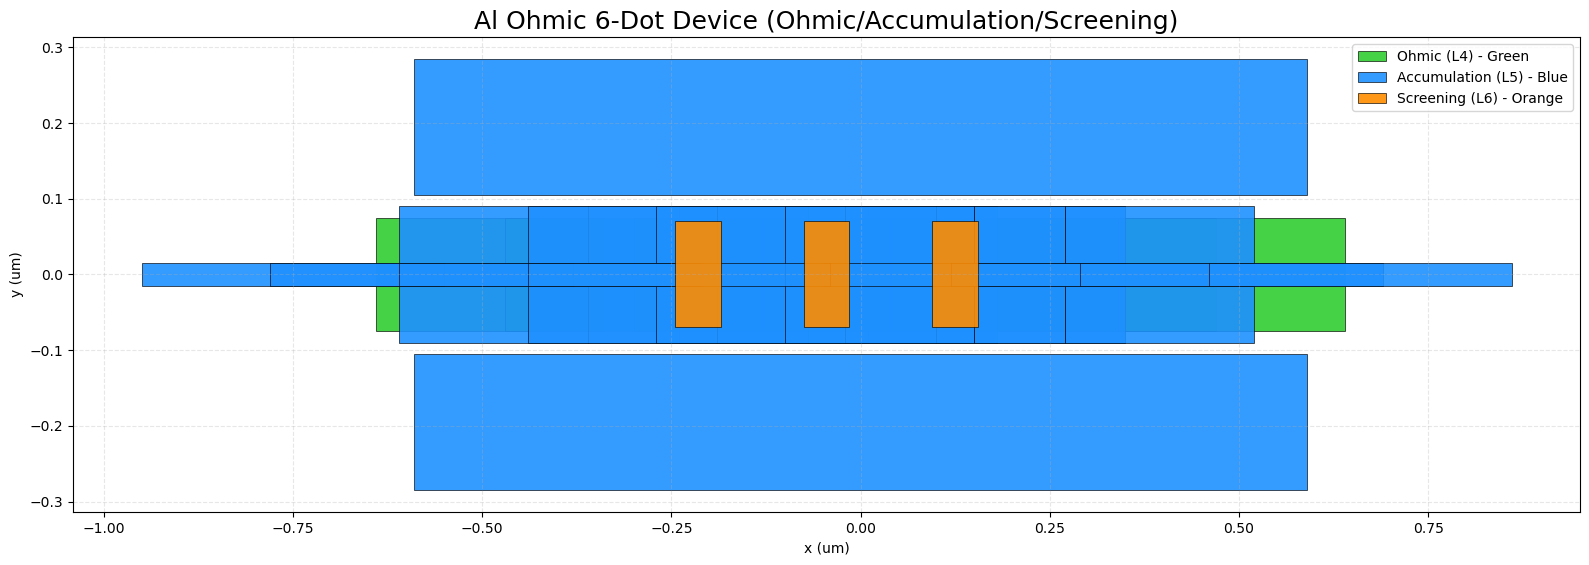

In [5]:
# Visualize Al ohmic device
fig, ax = plt.subplots(figsize=(16, 12))
ax.set_title("Al Ohmic 6-Dot Device (Ohmic/Accumulation/Screening)", fontsize=18)

# Layer color config - Green/Blue/Orange
layer_config = {
    4: {'color': '#32CD32', 'alpha': 0.9, 'label': 'Ohmic (L4) - Green'},
    5: {'color': '#1E90FF', 'alpha': 0.9, 'label': 'Accumulation (L5) - Blue'},
    6: {'color': '#FF8C00', 'alpha': 0.9, 'label': 'Screening (L6) - Orange'}
}

drawn_labels = set()

for layer in [4, 5, 6]:
    polygons = cell_ohmic.get_polygons(layer=layer, datatype=0)
    if not polygons:
        continue
    
    cfg = layer_config.get(layer)
    label = cfg['label']
    
    for gds_poly in polygons:
        pts = gds_poly.points
        if pts.ndim != 2 or len(pts) < 3:
            continue
        
        current_label = label if label not in drawn_labels else None
        poly = MplPolygon(pts, closed=True, facecolor=cfg['color'],
                         edgecolor='black', linewidth=0.5, alpha=cfg['alpha'],
                         label=current_label)
        ax.add_patch(poly)
        if current_label:
            drawn_labels.add(label)

handles, labels = ax.get_legend_handles_labels()
if handles:
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='upper right')

ax.set_aspect('equal')
ax.autoscale_view()
ax.set_xlabel('x (um)')
ax.set_ylabel('y (um)')
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## Generated Files

Files:
- `6qd_device_core.gds` - Standard 6-dot device
- `6qd_ohmic_design.gds` - Al ohmic device

In [6]:
# List generated files
print("Generated files:")
print("=" * 60)
for f in os.listdir(work_dir):
    filepath = os.path.join(work_dir, f)
    size = os.path.getsize(filepath)
    print(f"  {f}: {size/1024:.2f} KB")

print("\nDone!")

Generated files:
  6qd_device_core.gds: 4.09 KB
  6qd_ohmic_design.gds: 3.13 KB

Done!
